<a href="https://colab.research.google.com/github/ArthJain123/Diabetes-Prediction-ML/blob/main/Diabetes_Prediction_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

## Data Analysis

In [2]:
data = pd.read_csv("/content/Diabetes_Prediction_Project.csv")

# =================================== Data Analysis =======================================

print("Checking Top 10 Patients Data: \n",data.head(10))

print("\nTotal Number of Patients: \t",data.shape[0])
print("Total Number of Patients Data(Features): \n",data.shape[1])

print("\nChecking Data type stored in each feature:")
print(data.info())


Checking Top 10 Patients Data: 
    Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   
5            5      116             74              0        0  25.6   
6            3       78             50             32       88  31.0   
7           10      115              0              0        0  35.3   
8            2      197             70             45      543  30.5   
9            8      125             96              0        0   0.0   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1 

## Data Cleaning

In [3]:
# ===================================== Data Cleaning =====================================

# In the dataset
# It is impossible for having 0
# BloodPressure,SkinThickness,Insulin,BMI,Glucose

# Replacing 0 with Nan value

col = ["BloodPressure","SkinThickness","Insulin","BMI","Glucose"]

print("\nChecking for 0 value in Multiple Features: \n",data[col].eq(0).sum())

data[col] = data[col].replace(0,np.nan)

print("\nVerifying for 0 were converted into Nan values: \n",data[col].eq(0).sum())

print("\nChecking for Number of Nan/Missing value in dataset: \n",data.isnull().sum())

data[col] = data[col].fillna(data[col].median())

print("\nChecking for Duplicated record in dataset: \n",data.duplicated().sum())
# There is no Duplicate value in the whole dataset

print("\nVerifying for Nan/Missing value existence: \n",data.isnull().sum())




Checking for 0 value in Multiple Features: 
 BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
Glucose            5
dtype: int64

Verifying for 0 were converted into Nan values: 
 BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
Glucose          0
dtype: int64

Checking for Number of Nan/Missing value in dataset: 
 Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

Checking for Duplicated record in dataset: 
 0

Verifying for Nan/Missing value existence: 
 Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age             

## EDA(Exploratory Data Analysis) on "Outcome"

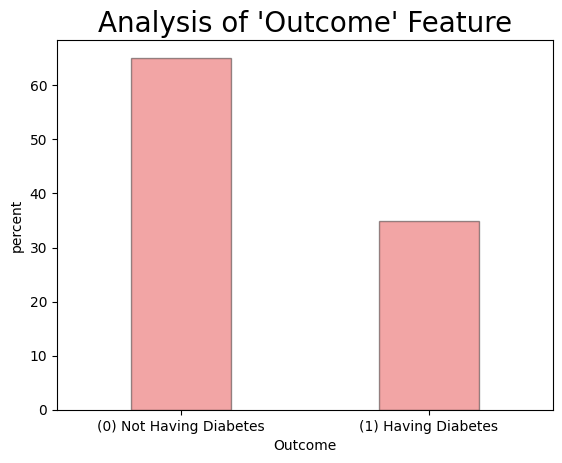

Number of Patients who not having Diabetes(0): 
 500
Number of Patients who having Diabetes(1): 
 268


In [4]:
# ================================== Analysis of 'Outcome' Feature =====================================


plt.title("Analysis of 'Outcome' Feature",fontsize = 20)

sns.countplot(x = "Outcome",data = data,color = "red",alpha = 0.4,width = 0.4,edgecolor = "black",stat = "percent")

plt.xticks([0,1],["(0) Not Having Diabetes","(1) Having Diabetes"])
plt.show()

print("Number of Patients who not having Diabetes(0): \n",data["Outcome"].value_counts().iloc[0])
print("Number of Patients who having Diabetes(1): \n",data["Outcome"].value_counts().iloc[1])



## Analysis between "Age and Outcome Features"

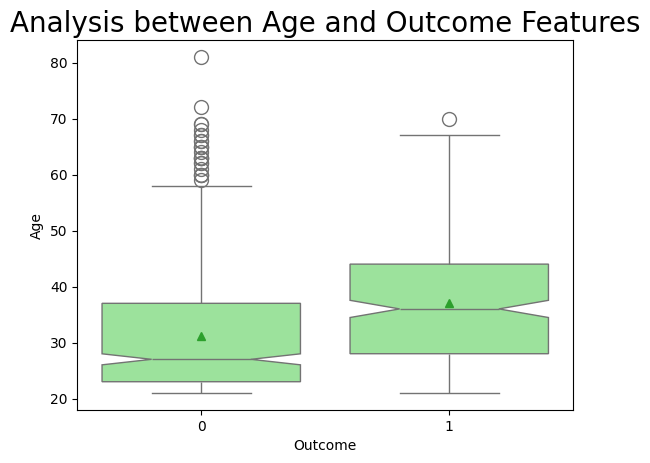


According to Data,
People who's age were around 25 to 40(young adulthood) are not having Diabetes
But there were some patients who's age were around 60 to 75 are not having Diabetes.

Most of People who's age were around 30 to 45 are having Diabetes.



In [5]:
# ================================ Analysis between "Age and Outcome Features" ====================================


plt.title("Analysis between Age and Outcome Features",fontsize = 20)

sns.boxplot(x = "Outcome",y = "Age",data = data,color = "lightgreen",showmeans = True,notch = True,fliersize = 10)
plt.show()

print("""
According to Data,
People who's age were around 25 to 40(young adulthood) are not having Diabetes
But there were some patients who's age were around 60 to 75 are not having Diabetes.

Most of People who's age were around 30 to 45 are having Diabetes.
""")



##Data Insights from "Glucose and Outcome Features"

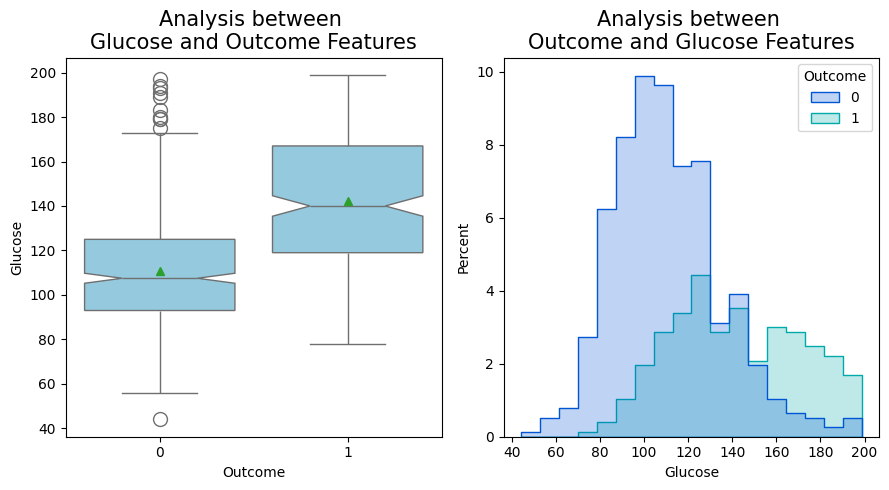


According to Data,
Patients who are having high glucose readings
having the chance of Diabetes disease.

Glucose have high positive correlation with Outcome Feature
which can lead Diabetes in future.



In [6]:
# =============================== Data Insights from "Glucose and Outcome Features" ============================

plt.figure(figsize = (9,5))

plt.subplot(1,2,1)

plt.title("Analysis between \nGlucose and Outcome Features",fontsize = 15)

sns.boxplot(x = "Outcome",y = "Glucose",data = data,showmeans = True,color = "skyblue",notch = True,fliersize = 10)


plt.subplot(1,2,2)

plt.title("Analysis between \nOutcome and Glucose Features",fontsize = 15)

sns.histplot(x = "Glucose",data = data,hue = "Outcome",hue_order = [0,1],palette = "winter",element = "step",stat = "percent")

plt.tight_layout()
plt.show()

print("""
According to Data,
Patients who are having high glucose readings
having the chance of Diabetes disease.

Glucose have high positive correlation with Outcome Feature
which can lead Diabetes in future.
""")



##Analysis between "Outcome and Blood Pressure Features"

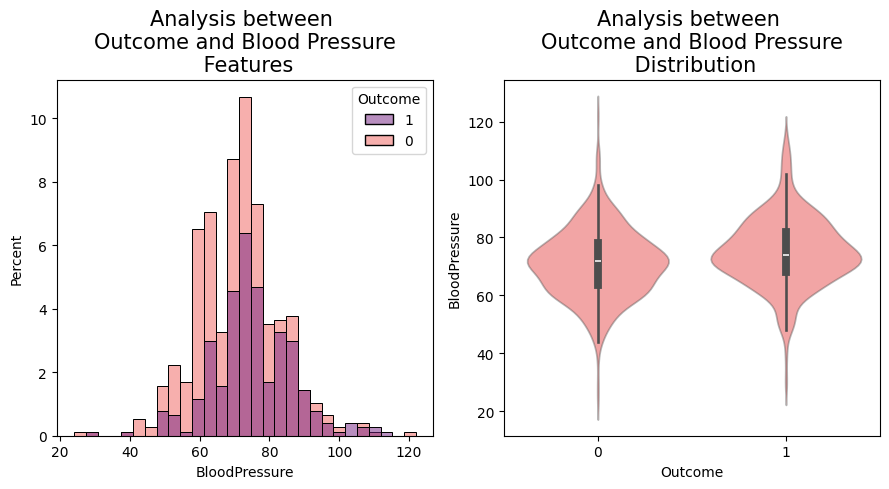


According to Data,
Blood Pressure is not a major factor for having Diabetes disease.

Having weak positive correlation between Blood Pressure and Outcome Features



In [7]:
# ================================= Analysis between "Outcome and Blood Pressure Features" ===============================

plt.figure(figsize = (9,5))

plt.subplot(1,2,1)

plt.title("Analysis between \nOutcome and Blood Pressure\n Features",fontsize = 15)

sns.histplot(x = "BloodPressure",data = data,hue = "Outcome",hue_order = [1,0],palette = "magma",stat = "percent")


plt.subplot(1,2,2)

plt.title("Analysis between \nOutcome and Blood Pressure\n Distribution",fontsize = 15)

sns.violinplot(x = "Outcome",y = "BloodPressure",data = data,color = "red",alpha = 0.4)

plt.tight_layout()
plt.show()

print("""
According to Data,
Blood Pressure is not a major factor for having Diabetes disease.

Having weak positive correlation between Blood Pressure and Outcome Features
""")



##Feature affecting Outcome Feature

Correaltion: 
                            Outcome
Outcome                   1.000000
Glucose                   0.492782
BMI                       0.312038
Age                       0.238356
Pregnancies               0.221898
SkinThickness             0.214873
Insulin                   0.203790
DiabetesPedigreeFunction  0.173844
BloodPressure             0.165723 



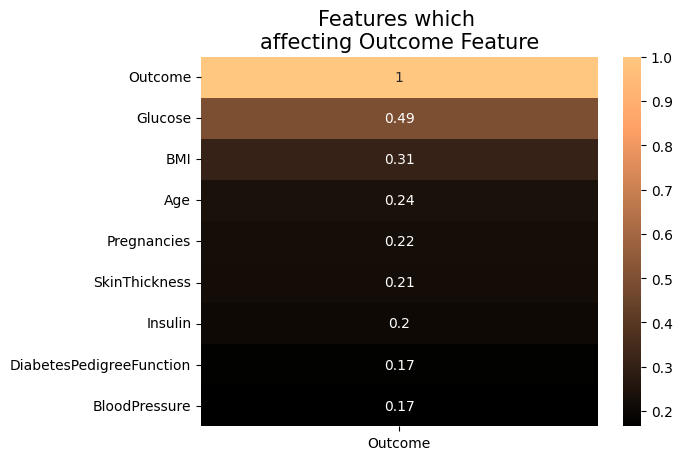

In [8]:
# ===================================== Feature affecting Outcome Feature =========================================


corr = data.corr()

corr_out = pd.DataFrame(dict(Outcome = corr["Outcome"].sort_values(ascending = False)))
print("Correaltion: \n",corr_out,"\n")

plt.title("Features which \naffecting Outcome Feature",fontsize = 15)

sns.heatmap(corr_out,cmap = "copper",annot = True)
plt.show()



##Data Selection

In [9]:
# ===================================== Data Selection =========================================


X = data.drop("Outcome",axis = 1)

y = data["Outcome"]

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state = 42)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

# Standarised the features due to KNN relay on distance calculation making all features in a same range



##Hyper Parameter Tuning

In [10]:
# ===================================== Hyper Parameter Tuning ======================================


py_li = []

for val in range(1,21):
      model = KNeighborsClassifier(n_neighbors = val)

      model.fit(X_train,y_train)
      pred_data = model.predict(X_test)

      KNN_acc = accuracy_score(y_test,pred_data)

      py_li.append(KNN_acc)

arr = np.array(py_li)
best_val = np.argmax(arr) + 1
print("Best K Value: \n",best_val)



Best K Value: 
 12


##KNN(K Nearest Neighbors)

In [11]:
# ==================================== KNN(K Nearest Neighbors) ====================================


model = KNeighborsClassifier(n_neighbors = best_val)

model.fit(X_train,y_train)

pred_data = model.predict(X_test)

KNN_acc = accuracy_score(y_test,pred_data)
print("\nAccuracy of model: \n",KNN_acc)

KNN_CM = confusion_matrix(y_test,pred_data)
print("\nConfusion_Matrix: \n",pd.DataFrame(dict(Predicted_Diabetes = KNN_CM[0],
                                                Predicted_No_Diabetes = KNN_CM[1]),index = ["Actual_Diabetes","Actual_No_Diabetes"]))

KNN_CR = classification_report(y_test,pred_data)
print("\nAll Model Matrics: \n",KNN_CR)




Accuracy of model: 
 0.7922077922077922

Confusion_Matrix: 
                     Predicted_Diabetes  Predicted_No_Diabetes
Actual_Diabetes                     87                     20
Actual_No_Diabetes                  12                     35

All Model Matrics: 
               precision    recall  f1-score   support

           0       0.81      0.88      0.84        99
           1       0.74      0.64      0.69        55

    accuracy                           0.79       154
   macro avg       0.78      0.76      0.77       154
weighted avg       0.79      0.79      0.79       154

